# Assignment 2: Detecting Contradictions in Law Documents

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Task 1 - Data preparation and exploration

Load the provided JSONL datasets, transform them into a format suitable for use with
your models. For the Slovene dataset, this may involve creating pairs of sections with binary labels (contradicting / not contradicting). For the English dataset, use the provided
labels directly or merge classes into binary categories if appropriate.
Perform basic exploratory analysis. Some examples of questions you might want to
answer are:
• Are there missing values or duplicate entries?
• How many examples are in the chosen dataset?
• How long are typical sections?
• Are contradictions balanced across the datasets?
Split the data into train, validation, and test sets. Prepare tokenized text representations suitable for traditional machine learning models.
Additionally, include a short data presentation and visualization section. Visualize the data distribution, text lengths, and example contradictions using tables and
graphs.

How many examples are in the chosen dataset?
There are 7191 examples in the english dataset.

In [2]:
train_data = pd.read_json("English dataset/train.jsonl", lines=True)
print(train_data.shape)
print(train_data.columns)
train_data.head(2)

(7191, 5)
Index(['doc_id', 'key', 'premise', 'hypothesis', 'label'], dtype='object')


,doc_id,key,premise,hypothesis,label
0,34,nda-11,,Receiving Party shall not reverse engineer any...,NotMentioned
1,34,nda-16,5. All Confidential Information in any form an...,Receiving Party shall destroy or return some C...,Entailment


In [3]:
train_data['label'].value_counts()

label
Entailment       3530
NotMentioned     2820
Contradiction     841
Name: count, dtype: int64

The dataset exhibits class imbalance, with contradiction instances being significaly less frequent that entailment and non-mentioned cases.

In [4]:
train_data['premise_len'] = train_data['premise'].apply(lambda x: len(x.split()))
train_data['hypothesis_len'] = train_data['hypothesis'].apply(lambda x: len(x.split()))

 How long are typical sections?
Premise texts are relatively long, with an average length of approximately 44 words, while hypothesis are averaging around 13 words. Premise lengths show high variance, with some exceeding 400 words. Hypothesis remain almost consistent in length.

In [5]:
train_data[['premise_len', 'hypothesis_len']].describe()

,premise_len,hypothesis_len
count,7191.000000,7191.000000
mean,44.050341,12.823529
std,51.913563,3.899521
min,0.000000,7.000000
25%,0.000000,10.000000
50%,34.000000,13.000000
75%,67.000000,14.000000
max,424.000000,23.000000


Are there missing values or duplicate entries?
Yes some values are missing, for example some premise fields are empty which we can see because the minimum length of the premise is zero. No missing values were observed in the hypothesis field.
There are several duplicated entries. Manual inspection confirmed that these repetitions correspond to identical legal clauses appearing across multiple documents.

In [6]:
train_data.duplicated(subset=['premise', 'hypothesis', 'label']).sum()

np.int64(2882)

In [7]:
dup_mask = train_data.duplicated(subset=['premise', 'hypothesis', 'label'], keep=False)
dups = train_data[dup_mask]
dups.head(5)[['premise', 'hypothesis', 'label', 'doc_id', 'key']]


,premise,hypothesis,label,doc_id,key
0,,Receiving Party shall not reverse engineer any...,NotMentioned,34,nda-11
4,,Confidential Information shall only include te...,NotMentioned,34,nda-2
8,,Receiving Party may retain some Confidential I...,NotMentioned,34,nda-20
10,,Receiving Party shall not solicit some of Disc...,NotMentioned,34,nda-18
17,,Receiving Party shall not reverse engineer any...,NotMentioned,86,nda-11


In [8]:
example = dups[['premise', 'hypothesis', 'label']].value_counts().head(1)
prem, hyp, lab = example.index[0]

train_data[(train_data['premise'] == prem) &
           (train_data['hypothesis'] == hyp) &
           (train_data['label'] == lab)]

,doc_id,key,premise,hypothesis,label,premise_len,hypothesis_len
0,34,nda-11,,Receiving Party shall not reverse engineer any...,NotMentioned,0,14
17,86,nda-11,,Receiving Party shall not reverse engineer any...,NotMentioned,0,14
34,87,nda-11,,Receiving Party shall not reverse engineer any...,NotMentioned,0,14
51,88,nda-11,,Receiving Party shall not reverse engineer any...,NotMentioned,0,14
68,89,nda-11,,Receiving Party shall not reverse engineer any...,NotMentioned,0,14
...,...,...,...,...,...,...,...
7106,620,nda-11,,Receiving Party shall not reverse engineer any...,NotMentioned,0,14
7123,621,nda-11,,Receiving Party shall not reverse engineer any...,NotMentioned,0,14
7140,622,nda-11,,Receiving Party shall not reverse engineer any...,NotMentioned,0,14
7157,623,nda-11,,Receiving Party shall not reverse engineer any...,NotMentioned,0,14


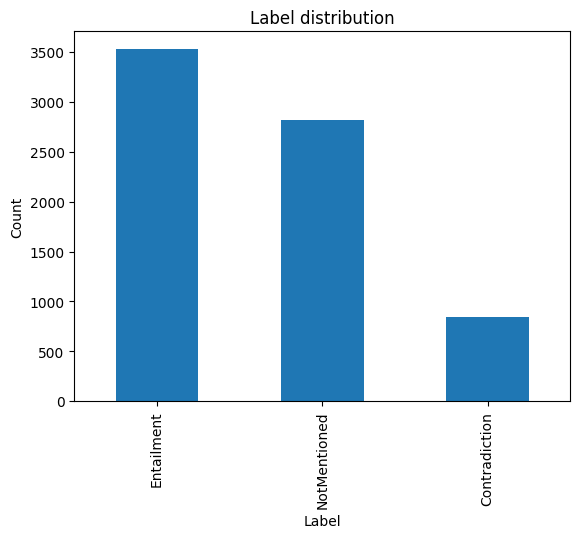

In [9]:
train_data['label'].value_counts().plot(kind='bar')
plt.title("Label distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

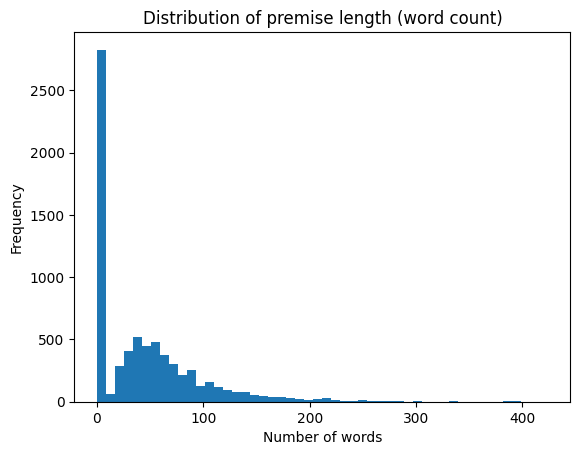

In [10]:
train_data['premise_len'].plot(kind='hist', bins=50)
plt.title("Distribution of premise length (word count)")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()

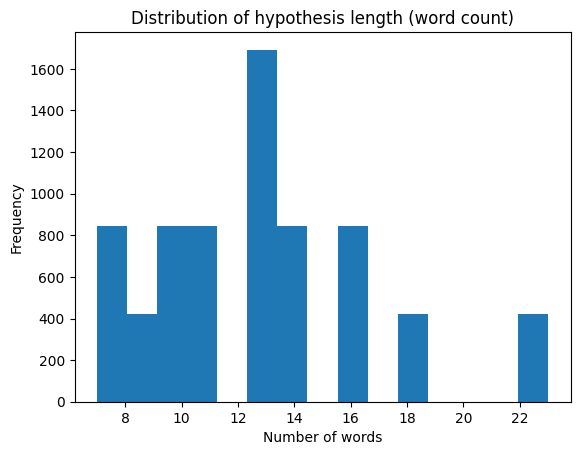

In [11]:
train_data['hypothesis_len'].plot(kind='hist', bins=15)
plt.title("Distribution of hypothesis length (word count)")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()

## Task 2 - Basic Machine Learning

In [12]:
train_data['premise'] = train_data['premise'].fillna('')
train_data['hypothesis'] = train_data['hypothesis'].fillna('')

train_data['y'] = (train_data['label'] == 'Contradiction').astype(int)
train_data['y'].value_counts()

y
0    6350
1     841
Name: count, dtype: int64

In [13]:
train_data['text'] = train_data['premise'].str.strip() + " [SEP] " + train_data['hypothesis'].str.strip()
train_data[['text', 'y']].head(2)


,text,y
0,[SEP] Receiving Party shall not reverse engin...,0
1,5. All Confidential Information in any form an...,0


In [14]:
from sklearn.model_selection import train_test_split
X = train_data['text']
y = train_data['y']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
y_train.mean(), y_test.mean()

(np.float64(0.11700278164116829), np.float64(0.11674774148714386))

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

logistic_reg = Pipeline([
    ("tfidf", TfidfVectorizer(lowercase=True, ngram_range=(1, 2), min_df=2)),
    ("lr", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

logistic_reg.fit(X_train, y_train)

y_pred = logistic_reg.predict(X_test)

print(classification_report(y_test, y_pred, digits=3))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0      0.988     0.913     0.949      1271
           1      0.581     0.917     0.711       168

    accuracy                          0.913      1439
   macro avg      0.785     0.915     0.830      1439
weighted avg      0.941     0.913     0.921      1439

[[1160  111]
 [  14  154]]


In [16]:
from sklearn.ensemble import RandomForestClassifier
random_forest = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        min_df=2
    )),
    ("rf", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced_subsample"
    ))
])

random_forest.fit(X_train, y_train)

y_pred_rf = random_forest.predict(X_test)

print(classification_report(y_test, y_pred_rf, digits=3))
print(confusion_matrix(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0      0.972     0.992     0.982      1271
           1      0.930     0.786     0.852       168

    accuracy                          0.968      1439
   macro avg      0.951     0.889     0.917      1439
weighted avg      0.967     0.968     0.967      1439

[[1261   10]
 [  36  132]]


In [17]:
from sklearn.svm import LinearSVC

svm = Pipeline([
    ("tfidf", TfidfVectorizer(lowercase=True, ngram_range=(1, 2), min_df=2)),
    ("svm", LinearSVC(class_weight="balanced", random_state=42))
])
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print(classification_report(y_test, y_pred_svm, digits=3))
print(confusion_matrix(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0      0.978     0.968     0.973      1271
           1      0.773     0.833     0.802       168

    accuracy                          0.952      1439
   macro avg      0.876     0.901     0.888      1439
weighted avg      0.954     0.952     0.953      1439

[[1230   41]
 [  28  140]]


In [18]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

def eval_binary(model, X, y, name):
    y_pred = model.predict(X)
    acc = accuracy_score(y, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y, y_pred, average=None, labels=[0, 1])

    return {
        "model": name,
        "accuracy": acc,
        "precision_1": p[1],
        "recall_1": r[1],
        "f1_1": f1[1],
    }

results = []
results.append(eval_binary(logistic_reg, X_test, y_test, "Logistic Regression (TF-IDF)"))
results.append(eval_binary(random_forest, X_test, y_test, "Random Forest (TF-IDF)"))
results.append(eval_binary(svm, X_test, y_test, "Linear SVM (TF-IDF)"))

results_df = pd.DataFrame(results).set_index("model").sort_values("f1_1", ascending=False)
results_df

,accuracy,precision_1,recall_1,f1_1
model,,,,
Random Forest (TF-IDF),0.968033,0.929577,0.785714,0.851613
Linear SVM (TF-IDF),0.952050,0.773481,0.833333,0.802292
Logistic Regression (TF-IDF),0.913134,0.581132,0.916667,0.711316


Among traditional machine learning models, Random forest achieved the highest F1 score for the contradiction class and Logistic regression the lowest. That means that Random forest has the best overall balance between precision and recall. However, Logistic regression achieved substantially higher recall, detecting a larger proportion of contradictions at the cost of more false positives. Linear SVM provided a more balanced trade-off between the two extremes.

In [19]:
test_data = pd.read_json("English dataset/test.jsonl", lines=True)

test_data['premise'] = test_data['premise'].fillna('')
test_data['hypothesis'] = test_data['hypothesis'].fillna('')
test_data['y'] = (test_data['label'] == 'Contradiction').astype(int)
test_data['text'] = test_data['premise'].str.strip() + " [SEP] " + test_data['hypothesis'].str.strip()

X_final_test = test_data['text']
y_final_test = test_data['y']

In [20]:
svm.fit(train_data['text'], train_data['y'])
y_test_svm = svm.predict(X_final_test)

print(classification_report(y_final_test, y_test_svm, digits=3))
print(confusion_matrix(y_final_test, y_test_svm))

              precision    recall  f1-score   support

           0      0.980     0.967     0.974      1871
           1      0.751     0.836     0.791       220

    accuracy                          0.954      2091
   macro avg      0.866     0.902     0.883      2091
weighted avg      0.956     0.954     0.955      2091

[[1810   61]
 [  36  184]]


In [21]:
logistic_reg.fit(train_data['text'], train_data['y'])
y_pred_logistic = logistic_reg.predict(X_final_test)
print(classification_report(y_final_test, y_pred_logistic, digits=3))
print(confusion_matrix(y_final_test, y_pred_logistic))

              precision    recall  f1-score   support

           0      0.985     0.925     0.954      1871
           1      0.580     0.877     0.698       220

    accuracy                          0.920      2091
   macro avg      0.782     0.901     0.826      2091
weighted avg      0.942     0.920     0.927      2091

[[1731  140]
 [  27  193]]


In [22]:
random_forest.fit(train_data['text'], train_data['y'])
y_pred_random_forest = random_forest.predict(X_final_test)
print(classification_report(y_final_test, y_pred_random_forest, digits=3))
print(confusion_matrix(y_final_test, y_pred_random_forest))

              precision    recall  f1-score   support

           0      0.970     0.991     0.980      1871
           1      0.905     0.736     0.812       220

    accuracy                          0.964      2091
   macro avg      0.937     0.864     0.896      2091
weighted avg      0.963     0.964     0.962      2091

[[1854   17]
 [  58  162]]


In [23]:
results = []
results.append(eval_binary(logistic_reg, X_final_test, y_final_test, "Logistic Regression (TF-IDF)"))
results.append(eval_binary(random_forest, X_final_test, y_final_test, "Random Forest (TF-IDF)"))
results.append(eval_binary(svm, X_final_test, y_final_test, "Linear SVM (TF-IDF)"))

results_df = pd.DataFrame(results).set_index("model").sort_values("f1_1", ascending=False)
results_df

,accuracy,precision_1,recall_1,f1_1
model,,,,
Random Forest (TF-IDF),0.964132,0.905028,0.736364,0.812030
Linear SVM (TF-IDF),0.953611,0.751020,0.836364,0.791398
Logistic Regression (TF-IDF),0.920134,0.579580,0.877273,0.698011


The classifiers were retrained on the full training dataset and evaluated once on the test set. The results are pretty much consistent with validation performance. Again random forest achieved the highest F1 score, with very high precision and much lower recall. Logistic regression showed the highest recall and SVM the most balanced scores.

##  Task 3 - Transformer-based Classifier

In [26]:
df_pandas = pd.read_json("English dataset/train.jsonl", lines=True)
df_pandas['premise'] = df_pandas['premise'].fillna('')
df_pandas['hypothesis'] = df_pandas['hypothesis'].fillna('')
df_pandas['y'] = (df_pandas['label'] == 'Contradiction').astype(int)


In [29]:
from transformers import AutoTokenizer
from transformers import DataCollatorWithPadding
from transformers import AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer
from datasets import Dataset

train_df, val_df = train_test_split(
    df_pandas[['premise', 'hypothesis', 'y']],
    test_size=0.2,
    random_state=42,
    stratify=df_pandas['y']
)

# Define the tokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

train_data = Dataset.from_pandas(train_df.reset_index(drop=True))
val_data   = Dataset.from_pandas(val_df.reset_index(drop=True))
train_data  = train_data.rename_column("y", "labels")
val_data = val_data.rename_column("y", "labels")


def preprocess_function(data):
    return tokenizer(data["premise"], data["hypothesis"], truncation=True, max_length=256)

tokenized_train = train_data.map(preprocess_function, batched=True)
tokenized_val = val_data.map(preprocess_function, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)

training_args= TrainingArguments(
    output_dir = './results',
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=32,
    num_train_epochs=1,
    weight_decay=0.01,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    tokenizer=tokenizer,
    data_collator=data_collator,
)

# trainer.train()

Map:   0%|          | 0/5752 [00:00<?, ? examples/s]

Map:   0%|          | 0/1439 [00:00<?, ? examples/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\larci\AppData\Local\Temp\ipykernel_5328\2390810009.py:42: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
C:\Users\larci\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Step,Training Loss
500,0.219200


RuntimeError: [enforce fail at inline_container.cc:664] . unexpected pos 436075648 vs 436075540

In [31]:
# trainer.save_model("./results_final")
# tokenizer.save_pretrained("./results_final")

('./results_final\\tokenizer_config.json',
 './results_final\\special_tokens_map.json',
 './results_final\\vocab.txt',
 './results_final\\added_tokens.json',
 './results_final\\tokenizer.json')

In [32]:
model = AutoModelForSequenceClassification.from_pretrained("./results_final")
tokenizer = AutoTokenizer.from_pretrained("./results_final")


In [36]:
test_df = pd.read_json("English dataset/test.jsonl", lines=True)
test_df["premise"] = test_df["premise"].fillna('')
test_df["hypothesis"] = test_df["hypothesis"].fillna('')
test_df["y"] = (test_df["label"] == "Contradiction").astype(int)

test_data = Dataset.from_pandas(test_df[["premise", "hypothesis", "y"]].reset_index(drop=True))
test_data = test_data.rename_column("y", "labels")

def preprocess_function(batch):
    return tokenizer(batch["premise"], batch["hypothesis"], truncation=True, max_length=256)

tokenized_test = test_data.map(preprocess_function, batched=True)
model = AutoModelForSequenceClassification.from_pretrained("./results_final")
tokenizer = AutoTokenizer.from_pretrained("./results_final")

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
trainer = Trainer(model=model, data_collator=data_collator)
pred = trainer.predict(tokenized_test)

y_pred = np.argmax(pred.predictions, axis=1)
y_true = pred.label_ids

print(classification_report(y_true, y_pred, digits=3))
print(confusion_matrix(y_true, y_pred))

Map:   0%|          | 0/2091 [00:00<?, ? examples/s]

C:\Users\larci\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


              precision    recall  f1-score   support

           0      0.979     0.982     0.981      1871
           1      0.842     0.823     0.832       220

    accuracy                          0.965      2091
   macro avg      0.911     0.902     0.906      2091
weighted avg      0.965     0.965     0.965      2091

[[1837   34]
 [  39  181]]


DistilBERT sequence classification model achieved precision 0.842, recall 0.823 and F1-score 0.832 for the contradiction class. Compared to TF-IDF, the model provides a strong balance between precision and recall. reducing false positives comparing to Logistic Regression while maintaining a higher recall that the Random Forest baseline.
Overall, the transformer model slightly outperforms the best traditional baseline on F1 for contradiction detection.